In [1]:
import torch
import nn4n

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N, C = 512, 100
model_cfg = {
            "input_dim":    C,
            "hidden_dim":   N,
            'output_dim':   C,
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.,
            "postact_noise":0.
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

Using device: cuda


In [3]:
import numpy as np
load_data_type = '2TS_1_data'

data = np.load(f'../time_exp/{load_data_type}.npy', allow_pickle=True).item()
test_inputs = data['test_inputs']
print(test_inputs.shape)

torch.Size([7, 200, 100])


In [4]:
# Load model weights 
model_dict = torch.load(f'../time_exp/2TS_1_rnn.pth', map_location=torch.device('cuda'))

Wrc_trained = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()
trained_brc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.bias'].cpu().numpy()

Win_trained = model_dict['readout_layer.weight'].cpu().numpy()
trained_bin = model_dict['readout_layer.bias'].cpu().numpy()

Wout_trained = model_dict['recurrent_layers.0.projection_layer.weight'].cpu().numpy()
trained_bout = model_dict['recurrent_layers.0.projection_layer.bias'].cpu().numpy()    

## Construct $W_{rc}$

In [241]:
# # Create a recurrent weight matrix
# Wrc = np.zeros((N,N))
# # # Assign negative weights to all elements of Wrc
# # Wrc = np.random.normal(loc=-0.003, scale=0.001, size=(N, N))
# # Initiate the diagonal elements
# diags = np.random.normal(loc=-0.15, scale=0.02, size=(N)) 
# Delta, gain, loss = 200, 0.002, 0.001
# # Set up limits for each row
# limits1 = np.linspace(Delta, 0, N, dtype=int)
# limits2 = np.linspace(0, Delta, N, dtype=int)
# for i in range(N):
#     Wrc[i,i] = diags[i]
#     for j in range(N):
#         if j > i and j < (i + limits1[i]):
#             Wrc[i,j] = (j-i) * gain
#         if j < i and j > (i - limits2[i]):
#             Wrc[i,j] = (j-i) * loss
    
# # Plot the Wrc matrix
# from matplotlib import pyplot as plt
# plt.figure(figsize=(4,3.5))
# # Set colorbar symmetric around zero
# plt.imshow(Wrc, cmap='coolwarm', vmin=-0.3, vmax=0.3)
# plt.colorbar(label='Weight value')
# plt.xlabel('Neuron index')
# plt.ylabel('Neuron index')
# plt.tight_layout()

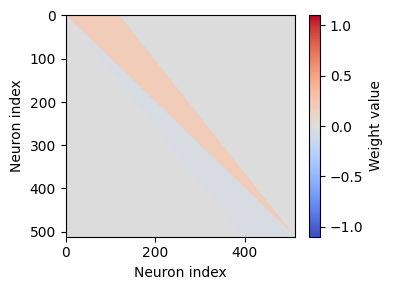

In [5]:
# Create a recurrent weight matrix
Wrc = np.zeros((N,N))
# Assign negative weights to all elements of Wrc
Wrc = np.random.normal(loc=-0.0025, scale=0.01, size=(N, N))
# Initiate the diagonal elements
diags = np.random.normal(loc=-0.15, scale=0.02, size=(N)) 
Delta, gain, loss = 120, 0.2, -0.05
# Set up limits for each row
limits1 = np.linspace(Delta, 0, N, dtype=int)
limits2 = np.linspace(0, Delta, N, dtype=int)
for i in range(N):
    Wrc[i,i] = diags[i]
    for j in range(N):
        if j > i and j < (i + limits1[i]):
            # Wrc[i,j] = (Delta+i-j) * gain
            Wrc[i,j] = gain
        if j < i and j > (i - limits2[i]):
            # Wrc[i,j] = (Delta-i+j) * loss
            Wrc[i,j] = loss
    
# Plot the Wrc matrix
from matplotlib import pyplot as plt
plt.figure(figsize=(4, 3))
# Set colorbar symmetric around zero
plt.imshow(Wrc, cmap='coolwarm', vmax=1.1, vmin=-1.1, aspect='auto')
plt.colorbar(label='Weight value')
plt.xlabel('Neuron index')
plt.ylabel('Neuron index')
plt.tight_layout()

plt.savefig('Wrc_theory.png', transparent=True, dpi=500)

np.save('Wrc_theory.npy', Wrc)

In [ ]:
# ------------------------------ Modify the idealised weights ------------------------------
model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(Wrc.astype(np.float32)).to(device)

In [7]:
rnn.load_state_dict(model_dict)
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)
test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
avg_fr = np.mean(hidden_states, axis=0)

(200, 333)


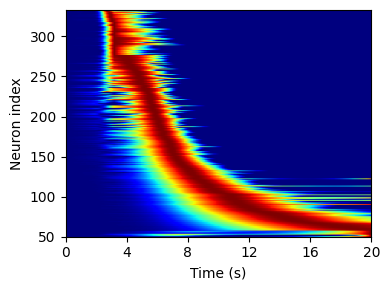

In [8]:
from matplotlib import pyplot as plt
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from func import plt_hs

fig, ax = plt.subplots(figsize=(4,3))
# # Sort avg fr based on the time of peak firing
# avg_fr_sorted = avg_fr[:, np.argsort(np.argmax(avg_fr, axis=0))]
# # Normalise avg_fr for better visualization
# for n in range(avg_fr_sorted.shape[1]):
#     if np.max(avg_fr_sorted[:, n]) - np.min(avg_fr_sorted[:, n]) == 0:
#         avg_fr_sorted[:, n] = 0
#     else:
#         avg_fr_sorted[:, n] = (avg_fr_sorted[:, n] - np.min(avg_fr_sorted[:, n])) / (np.max(avg_fr_sorted[:, n]) - np.min(avg_fr_sorted[:, n]))
# ax.imshow(avg_fr_sorted.T, aspect='auto', cmap='jet', extent=(0, avg_fr_sorted.shape[0]/10, 0, N))
norm_hs, fig, ax = plt_hs(avg_fr, ax=ax, fig=fig, min_fr=0.1)
print(norm_hs.shape)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron index')
ax.set_ylim(50, norm_hs.shape[1])
plt.tight_layout()

vis_idx = np.arange(50, norm_hs.shape[1])
vis_hs = norm_hs[:, vis_idx]
plt.savefig(f'theory_rnn_{load_data_type}_{N}_hs.png', transparent=True, dpi=300, bbox_inches='tight')

In [9]:
# Sort the norm_hs with maximum firing time
max_time_pts = np.argmax(vis_hs, axis=0)

threshold = 0.5
delta = 0.1

# For regions left to the max time pts, find the index where the firing rate is closest to 0.5 and between 0.6 and 0.4
firing_starts = np.zeros(vis_hs.shape[1])
for i in range(vis_hs.shape[1]):
    left_half = vis_hs[:max_time_pts[i], i]
    if np.any((left_half > threshold-delta) & (left_half < threshold+delta)):
        firing_starts[i] = np.where((left_half > threshold-delta) & (left_half < threshold+delta))[0][-1]
        
    else:
        firing_starts[i] = np.nan

# For regions right to the max time pts, find the index where the firing rate is closest to 0.5 and between 0.6 and 0.4
firing_ends = np.zeros(vis_hs.shape[1])
for i in range(vis_hs.shape[1]):
    right_half = vis_hs[max_time_pts[i]:, i]
    if np.any((right_half > threshold-delta) & (right_half < threshold+delta)):
        firing_ends[i] = max_time_pts[i] + np.where((right_half > threshold-delta) & (right_half < threshold+delta))[0][0]
    else:
        firing_ends[i] = np.nan

firing_widths = firing_ends - firing_starts

# Change the unit to time (s)
max_time_pts = max_time_pts / 10
firing_starts = firing_starts / 10
firing_ends = firing_ends / 10
firing_widths = firing_widths / 10

Fitted gradient: 0.5838
Correlation coefficient: 0.8821159384879327


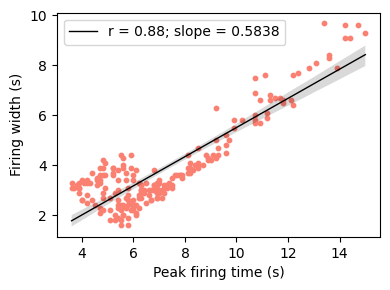

In [ ]:
# Plot the firing widths vs the maximum firing times
fig, ax = plt.subplots(figsize=(4,3))

time_start = 3.5
time_critical = 16 # inputs.shape[1]*(sensory_profile['time']['event_onset'][1]) / 10

plt.scatter(max_time_pts[(time_start <= max_time_pts) & (max_time_pts < time_critical)], 
            firing_widths[(time_start <= max_time_pts) & (max_time_pts < time_critical)], c='salmon', s=10)
plt.scatter(max_time_pts[(time_start <= max_time_pts) & (max_time_pts > time_critical)], 
            firing_widths[(time_start <= max_time_pts) & (max_time_pts > time_critical)], c='skyblue', s=10)

# Plot where not nan firing widths
not_nan_mask = ~np.isnan(firing_widths)
max_time_pts = max_time_pts[not_nan_mask]
firing_widths = firing_widths[not_nan_mask]
firing_starts = firing_starts[not_nan_mask]
firing_ends = firing_ends[not_nan_mask]
vis_hs = vis_hs[:, not_nan_mask]

from func import plt_corr
plt_corr(max_time_pts[(time_start <= max_time_pts) & (max_time_pts < time_critical)], 
         firing_widths[(time_start <= max_time_pts) & (max_time_pts < time_critical)], fig=fig, ax=ax)
plt.xlabel('Peak firing time (s)')
plt.ylabel("Firing width (s)")
plt.tight_layout()
plt.legend()
plt.savefig('time_exp_temp_corr.png', dpi=500, transparent=True, bbox_inches='tight')

## Structural analysis

In [11]:
# Load Wrc_theory
import numpy as np
Wrc_theory = np.load('Wrc_theory.npy')

In [30]:
# Load Wrc_space
model_dict = torch.load(f'../sq_space_exp/square_room_rnn.pth', map_location=torch.device('cuda'))
Wrc_space = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()

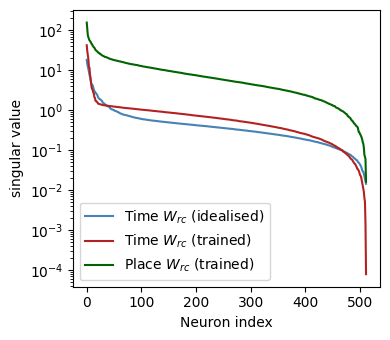

Singular values correlation (time): 0.9530485925533627
Singular values correlation (space): 0.8730551223250675
Normalized distance between singular value spectra (time): 0.916202631298307
Normalized distance between singular value spectra (space): 0.8401925


In [32]:
from matplotlib import pyplot as plt

U_tr, S_tr, Vt_tr = np.linalg.svd(Wrc_trained, full_matrices=False)
U_th, S_th, Vt_th = np.linalg.svd(Wrc_theory,  full_matrices=False)
U_sp, S_sp, Vt_sp = np.linalg.svd(Wrc_space,  full_matrices=False)

plt.figure(figsize=(4, 3.5))
plt.plot(S_th, color='steelblue', label=r'Time $W_{rc}$ (idealised)')
plt.plot(S_tr, color='firebrick', label=r'Time $W_{rc}$ (trained)')
plt.plot(S_sp, color='darkgreen', label=r'Place $W_{rc}$ (trained)')
plt.xlabel('Neuron index')
plt.ylabel('singular value')
plt.yscale('log')    
plt.legend()
plt.tight_layout()
plt.savefig('singular_values_comparison.png', transparent=True, dpi=500)
plt.show()

corr_S = np.corrcoef(S_tr, S_th)[0, 1]
corr_Sp = np.corrcoef(S_tr, S_sp)[0, 1]
print("Singular values correlation (time):", corr_S)
print("Singular values correlation (space):", corr_Sp)

# Calculate the distance between the singlar value spectra
diff_S_th = S_tr - S_th
diff_S_sp = S_tr - S_sp
norm_diff_S_th = np.linalg.norm(diff_S_th) / np.linalg.norm(S_th)
norm_diff_S_sp = np.linalg.norm(diff_S_sp) / np.linalg.norm(S_sp)
print("Normalized distance between singular value spectra (time):", norm_diff_S_th)
print("Normalized distance between singular value spectra (space):", norm_diff_S_sp)

In [33]:
from sklearn.decomposition import PCA

k = 20

X_tr = U_tr[:, :k].T   # (k, N)
X_th = U_th[:, :k].T   # (k, N)
X_sp = U_sp[:, :k].T   # (k, N)

X_all = np.vstack([X_tr, X_th, X_sp])   # (3k, N)

# PCA to 3D
pca = PCA(n_components=3)
Z_all = pca.fit_transform(X_all)  # (3k, 3)

Z_tr = Z_all[:k]  
Z_th = Z_all[k:2*k]  
Z_sp = Z_all[2*k:]  

(1536, 20)


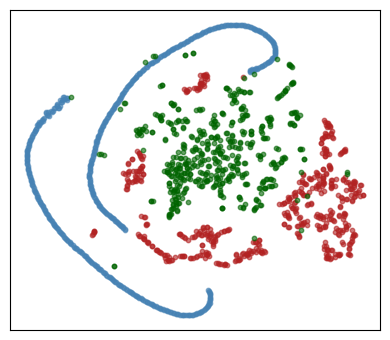

In [35]:
from sklearn.manifold import TSNE
U_tr_k = U_tr[:, :k]   # (N, k)
U_th_k = U_th[:, :k]   # (N, k)
U_sp_k = U_sp[:, :k]   # (N, k)
U_all = np.concatenate([U_tr_k, U_th_k, U_sp_k]) 
print(U_all.shape)
tsne = TSNE(n_components=2, perplexity=10, random_state=0)
U_tsne = tsne.fit_transform(U_all)

N = 512
Z_tr = U_tsne[:N]
Z_th = U_tsne[N:2*N]
Z_sp = U_tsne[2*N:]

# Plot
plt.figure(figsize=(4, 3.5))
plt.scatter(Z_th[:, 0], Z_th[:, 1], color='steelblue', label=r'Time $W_{rc}$ (idealised)', alpha=0.6, s=10)
plt.scatter(Z_tr[:, 0], Z_tr[:, 1], color='firebrick', label=r'Time $W_{rc}$ (trained)', alpha=0.6, s=10)
plt.scatter(Z_sp[:, 0], Z_sp[:, 1], color='darkgreen', label=r'Space $W_{rc}$ (trained)', alpha=0.6, s=10)
# plt.legend()
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('tsne.png', transparent=True, dpi=500)

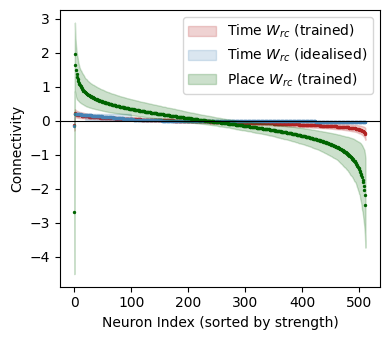

In [38]:
def sortW(W):
    # Iterate over rows of Wrc
    Wrc_sorted = np.zeros_like(W)
    for irow, row in enumerate(W):
        # Except itself, sort the indices of the other neurons by weight
        row_values = np.zeros_like(row)
        row_values[0] = row[irow]  # keep self-connection
        # Get the indices of other neurons sorted by weight
        other_indices = np.argsort(row)
        sorted_indices = [i for i in other_indices if i != irow]
        sorted_indices = sorted_indices[::-1]  # descending order
        # Fill in the row_values with sorted weights
        for j, idx in enumerate(sorted_indices):
            row_values[j + 1] = row[idx]
        Wrc_sorted[irow] = row_values
        
    mean_sorted = np.mean(Wrc_sorted, axis=0)
    percentile_16 = np.percentile(Wrc_sorted, 16, axis=0)
    percentile_84 = np.percentile(Wrc_sorted, 84, axis=0)
    return mean_sorted, percentile_16, percentile_84

mean_sorted, p16_time, p84_time = sortW(Wrc_trained)
mean_theory, p16_theory, p84_theory = sortW(Wrc_theory)
mean_space, p16_space, p84_space = sortW(Wrc_space)

# Plot the sorted Wrc
plt.figure(figsize=(4,3.5))
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.fill_between(range(len(mean_sorted)), p16_time, p84_time, alpha=0.2,
                 color='firebrick', label=r'Time $W_{rc}$ (trained)')
plt.scatter(range(len(mean_sorted)), mean_sorted, color='firebrick', s=2)
plt.fill_between(range(len(mean_theory)), p16_theory, p84_theory, alpha=0.2,
                 color='steelblue', label=r'Time $W_{rc}$ (idealised)')
plt.scatter(range(len(mean_theory)), mean_theory, color='steelblue', s=2)
plt.fill_between(range(len(mean_space)), p16_space, p84_space, alpha=0.2,
                 color='darkgreen', label=r'Place $W_{rc}$ (trained)')
plt.scatter(range(len(mean_space)), mean_space, color='darkgreen', s=2)
# plt.title('Wrc with Sorted Rows')
plt.legend(loc='upper right')
plt.xlabel('Neuron Index (sorted by strength)')
plt.ylabel('Connectivity')
# plt.yscale('symlog')
# plt.ylim(-0.6, 0.4)
plt.tight_layout()
plt.savefig('Connection_vs_distance.png', transparent=True, dpi=500)

mean_upper= 0.0219126997549491  mean_lower= -0.006682336399543101
max Re(λ) = 5.3360896
spectral radius = 28.139124


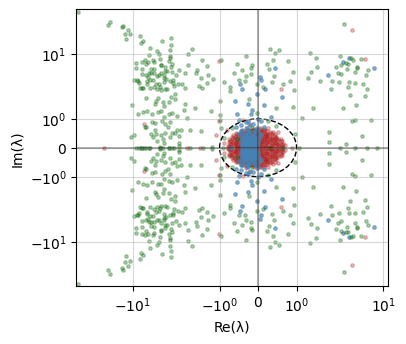

In [40]:
eig_time = np.linalg.eigvals(Wrc_trained)
eig_space = np.linalg.eigvals(Wrc_space)
eig_theory = np.linalg.eigvals(Wrc_theory)
plt.figure(figsize=(4,3.5))
plt.scatter(eig_time.real, eig_time.imag, s=6, c='firebrick', alpha=0.3, label=r'Time $W_{rc}$ (trained)')
# Plot a circle of radius 1
circle = plt.Circle((0, 0), 1.0, color='black', alpha=1, linestyle='--', fill=False)
plt.gca().add_artist(circle)
plt.scatter(eig_theory.real, eig_theory.imag, s=6, c='steelblue', alpha=0.6, label=r'Time $W_{rc}$ (idealised)')
plt.scatter(eig_space.real, eig_space.imag, s=6, c='darkgreen', alpha=0.3, label=r'Place $W_{rc}$ (trained)')
plt.axhline(0,c='k', alpha=0.3); plt.axvline(0,c='k', alpha=0.3)
plt.xlabel('Re(λ)'); plt.ylabel('Im(λ)')
plt.grid(True, alpha=0.5)
# plt.legend()
plt.tight_layout()
plt.xscale('symlog')
plt.yscale('symlog')
plt.savefig('eigen_spectrum.png', transparent=True, dpi=500)
# plt.title('Eigen spectrum')
upper = np.triu(Wrc, 1); lower = np.tril(Wrc, -1)
print('mean_upper=', np.nanmean(upper), ' mean_lower=', np.nanmean(lower))
print("max Re(λ) =", np.max(eig_time.real))
print("spectral radius =", np.max(np.abs(eig_time)))